In [1]:
import torch
import sys, os
import math as mt

src_dir = os.path.join(os.path.abspath(''), '..')  # goes up from models/ to src/
sys.path.insert(0, os.path.abspath(src_dir))

In [2]:
from models.autoencoder import Autoencoder
from models.autoencoder import trainSAE, testSAE
from utils.data_loading import QMatrixData

K = 5
lr = 5e-4
train_epochs = 500
in_channels = 4 
num_channels = 10
kernel_dim = 2
maze_dim = 4
batch_size = 10
gamma_sparse = 1/20*mt.sqrt(maze_dim**2*in_channels/K)
device = None

In [3]:
import numpy as np
import random

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [4]:
BASE_DIR = os.path.abspath(os.path.join(os.path.abspath(''), '..', '..', '..'))

train_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestraining_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstraining_4x4.pkl")
)
test_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestest_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstest_4x4.pkl")
)

autoencoder = Autoencoder(in_channels, maze_dim, num_channels, kernel_dim, K)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

# training language
total_losses, recon_losses, sparsity_losses, all_messages = trainSAE(autoencoder, train_dataset, gamma_sparse, optimizer, batch_size, train_epochs, device)

# getting messages from trained language
_, _, _, all_messages = testSAE(autoencoder, train_dataset, batch_size, gamma_sparse, device)

/Users/melodycui/Downloads/cos435_final_project/.venv/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.B

total loss: 629.53125
reconstruction loss: 627.8997802734375
sparsity loss: 1.6314960718154907

total loss: 569.7539672851562
reconstruction loss: 568.7512817382812
sparsity loss: 1.002693772315979

total loss: 471.0302429199219
reconstruction loss: 470.1476135253906
sparsity loss: 0.8826367259025574

total loss: 341.206298828125
reconstruction loss: 340.210693359375
sparsity loss: 0.9955613017082214

total loss: 251.17630004882812
reconstruction loss: 250.39366149902344
sparsity loss: 0.7826244831085205

total loss: 222.11968994140625
reconstruction loss: 221.6276397705078
sparsity loss: 0.4920382499694824

total loss: 217.16586303710938
reconstruction loss: 216.76220703125
sparsity loss: 0.4036524295806885

total loss: 214.2318572998047
reconstruction loss: 213.86593627929688
sparsity loss: 0.3658950626850128

total loss: 212.3590087890625
reconstruction loss: 212.0030517578125
sparsity loss: 0.3559587597846985

total loss: 210.63470458984375
reconstruction loss: 210.28074645996094
s

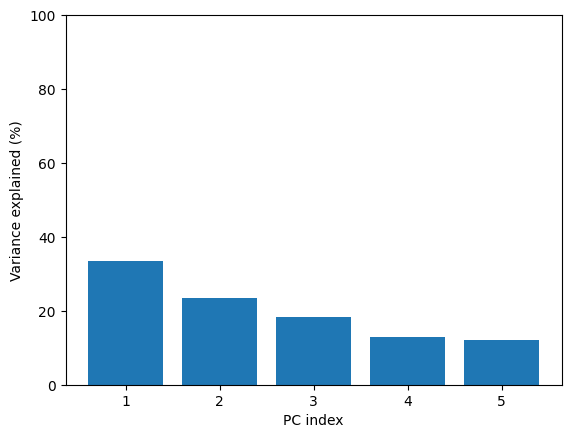

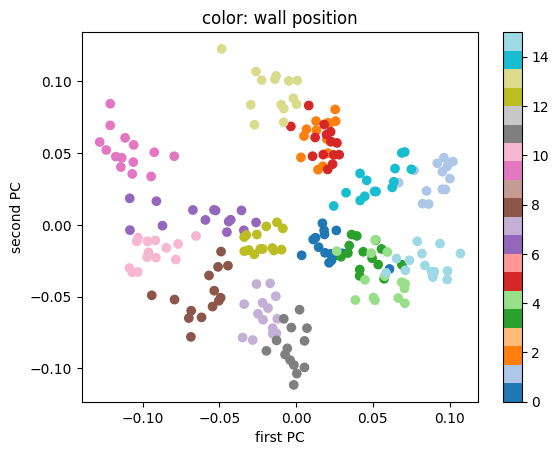

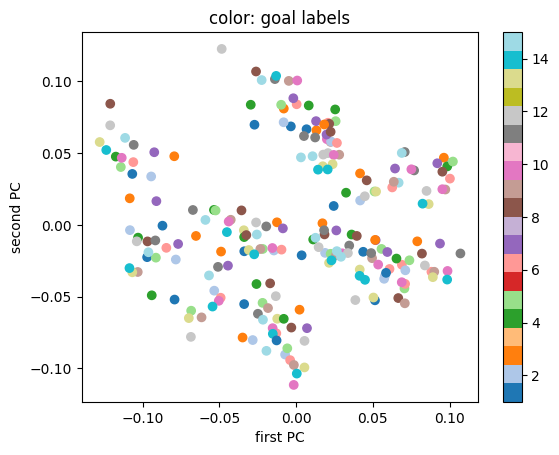

In [5]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

# Stack all messages into a single tensor
messages = torch.cat(all_messages, dim=0)  # shape: (num_tasks, K)
messages_np = messages.numpy()

wall_labels = [train_dataset.labels[i][0] for i in range(225)]
goal_labels = [train_dataset.labels[i][2] for i in range(225)]

pca = PCA(n_components=5)
pca_result = pca.fit_transform(messages_np)

# get plots
plot_pca_variance(pca)
plot_pca_by_label(pca_result, wall_labels, "color: wall position")
plot_pca_by_label(pca_result, goal_labels, "color: goal labels")